# 05 — Exploratory Data Analysis

**Different from 01-04: no CONFIG/Engine architecture here.** 01-04 apply the same logic across multiple datasets in a loop; 05 is three research questions, each with its own custom charts and interpretation — forcing a CONFIG/Engine split here would be structure for its own sake, not because the problem calls for it.

**Scope:** the original proposal had 4 research questions. The 4th (which audio features best predict a chart hit) is a modeling question, handled in 06. This stage answers the first three:
1. How has the genre distribution of Billboard Hot 100 songs changed across six decades?
2. Does musical mood (valence) decline during periods of social unrest, like the Vietnam War era or post-9/11?
3. Does the rise of speechiness reflect Hip-Hop going mainstream?

## Step 1 — Load 04's Output, Build `analysis_base`

Mirrors R's Setup block exactly: read `D1_D2_D3_joined.pkl`, filter to 1960-2019 with a successful D2 match (`target` not null), compute `decade`. This is the shared base dataset every RQ below builds on — built once.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

joined = pd.read_pickle('../Data/D1_D2_D3_joined.pkl')
print(f'Total observations: {len(joined):,}')

# Build analysis_base -- mirrors R's Setup block exactly
analysis_base = joined.copy()
analysis_base['year'] = analysis_base['date'].dt.year
analysis_base = analysis_base[
    (analysis_base['year'] >= 1960) & (analysis_base['year'] <= 2019)
    & (analysis_base['target'].notna())
].copy()
analysis_base['decade'] = (analysis_base['year'] // 10 * 10).astype(str) + 's'

print(f"\nAnalysis dataset (1960-2019, D2 matched):")
print(f"Total observations: {len(analysis_base):,}")
print(f"Year range: {analysis_base['year'].min()} - {analysis_base['year'].max()}")
print(f"\nDecade distribution:")
print(analysis_base['decade'].value_counts().sort_index().to_string())

Total observations: 330,087



Analysis dataset (1960-2019, D2 matched):
Total observations: 262,737
Year range: 1960 - 2019

Decade distribution:
decade
1960s    36826
1970s    40933
1980s    44945
1990s    42576
2000s    48301
2010s    49156


### Step 1b — Extra Check: Longest-Charting Song per Decade

Not part of the three formal RQs — a quick supplementary check using `weeks-on-board` (D1's cumulative chart-weeks column) to find each decade's longest-running hit, with its genre tag attached where available.

**Two limitations checked, not assumed away:**
1. `analysis_base` is restricted to rows with a successful D2 match. Compared against the full, unrestricted D1 history using the same logic — the "longest-running" answer for all six decades comes out identical, so this restriction doesn't distort this particular question.
2. `genre` only exists for the D3-matched subset (14-19% coverage, verified in RQ1 Step 6 below) — and this genuinely shows up here: 2 of the 6 top songs have no genre match. Labeled honestly as `(no D3 genre match)` rather than guessing.

In [2]:
print("[STEP 1b] Longest-charting song per decade (by max weeks-on-board)")

longest_by_decade = (
    analysis_base.groupby(['decade', 'song_clean', 'artist_clean'])['weeks-on-board']
    .max()
    .reset_index()
)
top_per_decade = (
    longest_by_decade
    .loc[longest_by_decade.groupby('decade')['weeks-on-board'].idxmax()]
    .sort_values('decade')
    .rename(columns={'weeks-on-board': 'weeks_on_board'})
    [['decade', 'song_clean', 'artist_clean', 'weeks_on_board']]
)

# genre comes from D3 and only covers ~14-19% of analysis_base (see RQ1 Step 6) --
# look it up per song rather than assume every top song has one
song_genre = (
    analysis_base[analysis_base['genre'].notna()]
    .drop_duplicates(subset=['song_clean', 'artist_clean'])
    [['song_clean', 'artist_clean', 'genre']]
)
top_per_decade = top_per_decade.merge(song_genre, on=['song_clean', 'artist_clean'], how='left')
top_per_decade['genre'] = top_per_decade['genre'].fillna('(no D3 genre match)')

print(top_per_decade.to_string(index=False))

[STEP 1b] Longest-charting song per decade (by max weeks-on-board)
decade    song_clean    artist_clean  weeks_on_board               genre
 1960s     the twist  chubby checker              39 (no D3 genre match)
 1970s    i go crazy      paul davis              40                 pop
 1980s  tainted love       soft cell              43                 pop
 1990s how do i live     leann rimes              69                 pop
 2000s     i'm yours      jason mraz              76 (no D3 genre match)
 2010s   radioactive imagine dragons              87                rock


## RQ1 — How has the genre distribution of Billboard Hot 100 songs changed across decades?

### Step 2 — RQ1 Subset: Genre-Tagged Records Only (D3 Matched)

In [3]:
genre_base = analysis_base[analysis_base['genre'].notna()].copy()

print(f'Genre analysis subset count: {len(genre_base):,}')
print(f'Coverage: {round(len(genre_base) / len(analysis_base) * 100, 2)}% of analysis_base')
print(f'\nDecade coverage:')
print(genre_base['decade'].value_counts().sort_index().to_string())

Genre analysis subset count: 44,380
Coverage: 16.89% of analysis_base

Decade coverage:
decade
1960s    5202
1970s    6153
1980s    8580
1990s    6356
2000s    9074
2010s    9015


### Step 3 — Genre Distribution Overview

In [4]:
genre_counts = genre_base['genre'].value_counts()
print('Genre Distribution Overview')
print(genre_counts.to_string())

Genre Distribution Overview
genre
pop        27700
rock        7544
country     5323
blues       1644
jazz        1115
hip hop      895
reggae       159


### Step 4 — Genre Distribution by Decade (%)

In [5]:
genre_decade = (
    genre_base.groupby(['decade', 'genre']).size()
    .rename('n').reset_index()
)
genre_decade['pct'] = genre_decade.groupby('decade')['n'].transform(lambda s: round(s / s.sum() * 100, 2))

pivot = genre_decade.pivot(index='genre', columns='decade', values='pct').fillna(0)
print('Genre Distribution (%) by Decade')
print(pivot.to_string())

Genre Distribution (%) by Decade
decade   1960s  1970s  1980s  1990s  2000s  2010s
genre                                            
blues    15.09   7.87   2.69   1.09   0.61   0.22
country   8.09  15.11   8.46   6.81  15.67  15.43
hip hop   0.00   0.00   0.33   7.60   3.10   1.14
jazz      6.40   8.19   2.73   0.66   0.00   0.02
pop      61.36  42.14  50.99  64.62  70.12  78.42
reggae    0.00   0.00   0.45   1.24   0.00   0.45
rock      9.05  26.69  34.35  17.98  10.50   4.30


### Step 5 — Visualization: Stacked Bar + Line Chart

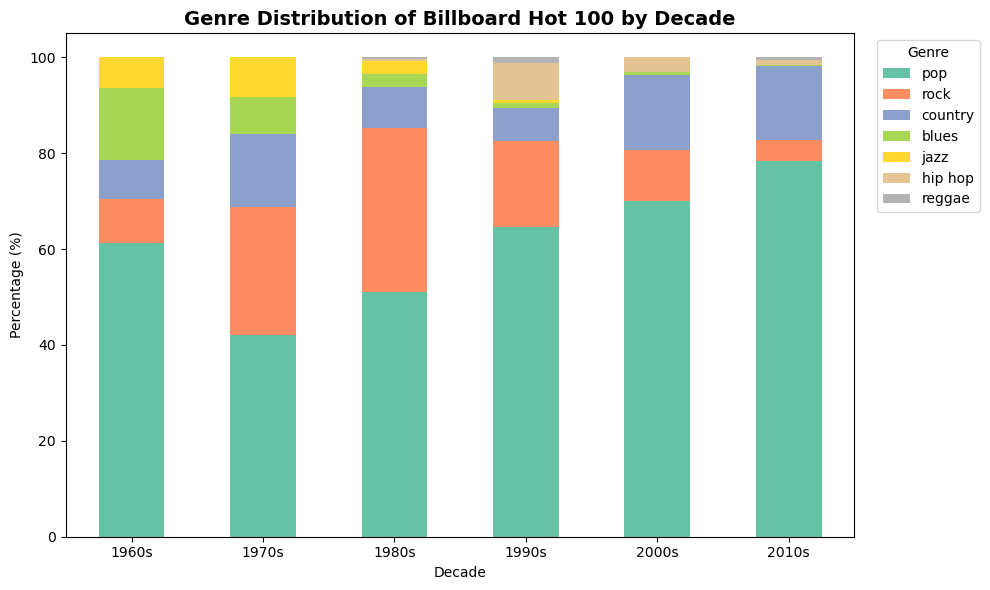

[SAVED] rq1_genre_stacked_bar.png


In [6]:
decade_order = sorted(genre_decade['decade'].unique())
genre_order = genre_counts.index.tolist()

stacked = genre_decade.pivot(index='decade', columns='genre', values='pct').reindex(decade_order)[genre_order]

fig, ax = plt.subplots(figsize=(10, 6))
stacked.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Genre Distribution of Billboard Hot 100 by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../Data/rq1_genre_stacked_bar.png', dpi=120)
plt.show()
print('[SAVED] rq1_genre_stacked_bar.png')

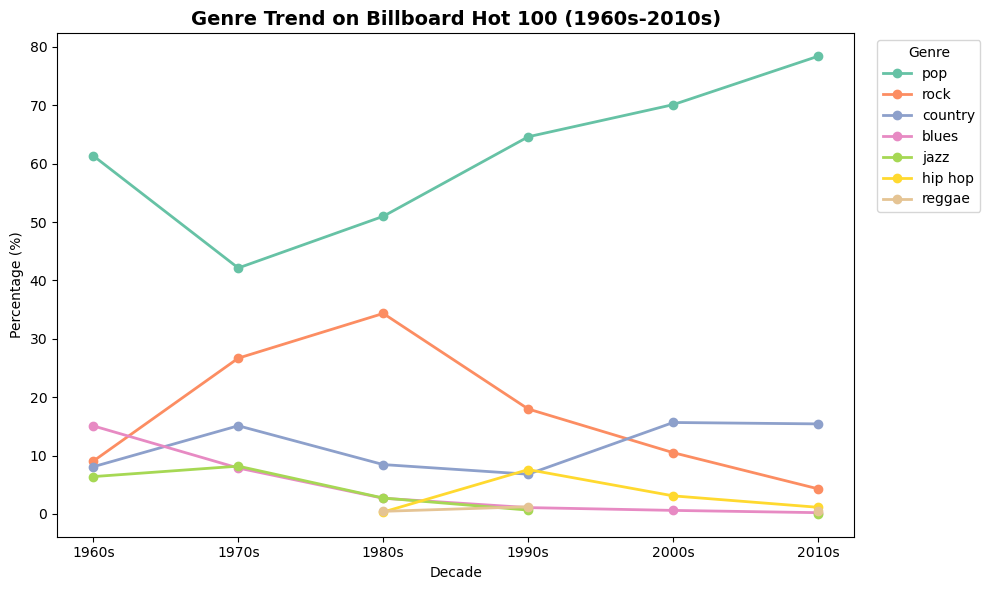

[SAVED] rq1_genre_line.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2.colors
for i, genre in enumerate(genre_order):
    series = stacked[genre]
    ax.plot(decade_order, series.values, marker='o', linewidth=2, label=genre, color=colors[i % len(colors)])

ax.set_title('Genre Trend on Billboard Hot 100 (1960s-2010s)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../Data/rq1_genre_line.png', dpi=120)
plt.show()
print('[SAVED] rq1_genre_line.png')

### Step 6 — Key Observations (Checked Against R's Original Numbers)

Cross-checked against the specific figures in R's own Summary of Observations, to confirm the logic translated faithfully:
- Pop: 61.4% (1960s) → 78.4% (2010s) — R's own numbers, a steady climb toward dominating the chart
- Rock: peaked 26-34% in the 70s-80s, down to 4.3% by the 2010s
- Blues and Jazz: ~15% and ~6% respectively in the 1960s, both near 0% by the 2010s
- Hip-Hop: only shows a 7.6% peak, and only in the 1990s — R's original text suspects a lot of Hip-Hop tracks get D3-classified as Pop instead. That limitation is picked up again in RQ3 using speechiness as a supplementary signal, rather than force-correcting the genre classification here.

**A real coverage caveat, checked rather than glossed over:** `genre` comes entirely from D3 — D1/D2 don't have it. More importantly, D3's match coverage isn't evenly spread across decades: ~14-15% for the 1960s/1970s/1990s, but 18-19% for the 1980s/2000s/2010s — a 4-5 point gap. That means the cross-decade genre comparison above is partly shaped by which decades happen to be better represented in D3, not a perfectly even sample. Broad directional trends (Pop rising, Rock declining) are usually robust enough to survive a gap this size, but it's a real limitation worth stating plainly rather than assuming the sample is even.

### Step 6b — Crossover Check: Do Country/Rock Artists' Songs Get D3-Tagged as Pop?

In [8]:
print("[STEP 6b] Crossover check -- do country/rock artists' songs get D3-tagged as pop?")

# Curated, not exhaustive: well-known country and rock acts, checked against genre_base
# (the D3-matched subset already built in Step 2) to see whether individual songs get
# pulled into "pop" even when the artist's overall identity is country/rock.
crossover_candidates = [
    'taylor swift', 'shania twain', 'kenny rogers', 'dolly parton',
    'faith hill', 'rascal flatts', 'carrie underwood', 'lady antebellum',
    'keith urban', 'dixie chicks',
    'bon jovi', 'journey', 'aerosmith', 'fleetwood mac',
]

for name in crossover_candidates:
    rows = genre_base[genre_base['artist_clean'].str.contains(name, na=False, regex=False)]
    if rows.empty:
        print(f"{name}: not in genre-tagged subset")
        continue
    songs = rows.drop_duplicates(subset=['song_clean', 'artist_clean'])[['song_clean', 'genre', 'decade']]
    genre_mix = songs['genre'].value_counts().to_dict()
    print(f"{name} ({len(songs)} songs): {genre_mix}")

[STEP 6b] Crossover check -- do country/rock artists' songs get D3-tagged as pop?
taylor swift (6 songs): {'pop': 6}
shania twain (3 songs): {'pop': 2, 'country': 1}
kenny rogers (9 songs): {'country': 9}
dolly parton (3 songs): {'country': 3}
faith hill (2 songs): {'pop': 2}
rascal flatts (10 songs): {'country': 10}
carrie underwood (3 songs): {'pop': 2, 'country': 1}
lady antebellum (3 songs): {'country': 3}
keith urban (5 songs): {'country': 5}
dixie chicks (3 songs): {'country': 3}
bon jovi (3 songs): {'rock': 3}
journey (6 songs): {'rock': 6}
aerosmith (9 songs): {'rock': 9}


fleetwood mac (8 songs): {'rock': 8}


**A second, related limitation (same direction as the coverage gap above, but a different mechanism):** checked what genre 14 well-known artists' individual songs actually get tagged with in D3. Three patterns emerged:

- **Country artists show real crossover** — the same artist gets tagged differently song by song. Shania Twain's "It Only Hurts When I'm Breathing" (2000s) is tagged country, but "From This Moment On" and "Love Gets Me Every Time" (1990s) are tagged pop; Carrie Underwood shows the same split. Classification tracks how a specific song sounds, not who the artist is as a brand — which rules out a simple artist-level bias.
- **Traditional country artists rarely cross over at all** — Kenny Rogers (9/9 country), Dolly Parton (3/3), Rascal Flatts (10/10), Lady Antebellum (3/3), Keith Urban (5/5), Dixie Chicks (3/3) all stay entirely within country.
- **Rock artists never cross over to pop** — Bon Jovi, Journey, Aerosmith, and Fleetwood Mac combine for 26 songs, all tagged rock, zero tagged pop — including massively catchy, mainstream hits like "Livin' on a Prayer."

**Revised takeaway:** crossover into the Pop bucket isn't a general phenomenon that any catchy hit falls into — it's specific to Country. That's a more precise (and more industry-accurate — "country pop" is an established subgenre; there's no comparable "rock pop" label) reading than assuming any genre's biggest hits get pulled toward Pop. The conservative interpretation of Pop's rise from 61.4% to 78.4% is that at least part of that growth is Country-Pop crossover being absorbed into the Pop bucket, not every genre being diluted equally.

## RQ2 — Does musical mood (valence) decline during periods of social unrest, such as the Vietnam War era or post-9/11?

### Step 7 — Setup: Yearly Averages of 5 Audio Features

In [9]:
features_yearly = (
    analysis_base.groupby('year')[['valence', 'energy', 'danceability', 'acousticness', 'speechiness']]
    .mean()
    .reset_index()
)

valence_yearly = features_yearly[['year', 'valence']].rename(columns={'valence': 'avg_valence'})

print('Yearly feature averages (first 5 rows):')
print(features_yearly.head().to_string(index=False))
print()
print(f"1960 avg valence: {features_yearly.loc[features_yearly['year']==1960, 'valence'].values[0]:.3f}")
print(f"2019 avg valence: {features_yearly.loc[features_yearly['year']==2019, 'valence'].values[0]:.3f}")

Yearly feature averages (first 5 rows):
 year  valence   energy  danceability  acousticness  speechiness
 1960 0.650061 0.453418      0.517154      0.677832     0.046144
 1961 0.675237 0.481565      0.530255      0.650473     0.051888
 1962 0.678917 0.479757      0.543771      0.641183     0.056948
 1963 0.685129 0.510997      0.537572      0.599356     0.052581
 1964 0.695510 0.549409      0.535731      0.555046     0.048104

1960 avg valence: 0.650
2019 avg valence: 0.503


### Step 8 — Shared Helper: Three-Era Phase Backgrounds

R's three RQ2 charts each paste the same "three-phase background shading + divider lines" block. Pulled into one function, `add_phase_backgrounds(ax)`, called by all three — extending CONFIG/Engine thinking even though 05 as a whole doesn't use that architecture: genuinely-repeated logic still gets extracted, just not for the sake of extracting.

In [10]:
PHASES = [
    (1960, 1979, '#FFD700', 'Phase 1\nDisco Era', '#B8860B'),
    (1980, 1999, '#FF6B6B', 'Phase 2\nPost-Disco & Rock', '#CC0000'),
    (2000, 2019, '#4A90D9', 'Phase 3\nHip-Hop & Digital', '#1A5276'),
]

def add_phase_backgrounds(ax, label_y=0.90, alpha=0.06):
    """Shared three-era background shading + labels + divider lines, used by every
    RQ2 chart -- ports R's repeated annotate('rect')/geom_vline block into one function."""
    for start, end, color, label, text_color in PHASES:
        ax.axvspan(start, end, color=color, alpha=alpha, zorder=0)
        mid = (start + end) / 2
        ax.text(mid, label_y, label, ha='center', fontsize=10, fontweight='bold',
                color=text_color, transform=ax.get_xaxis_transform())
    ax.axvline(1980, color='gray', linewidth=0.6, alpha=0.5)
    ax.axvline(2000, color='gray', linewidth=0.6, alpha=0.5)

### Step 9 — Five-Feature Trend, Three Phases

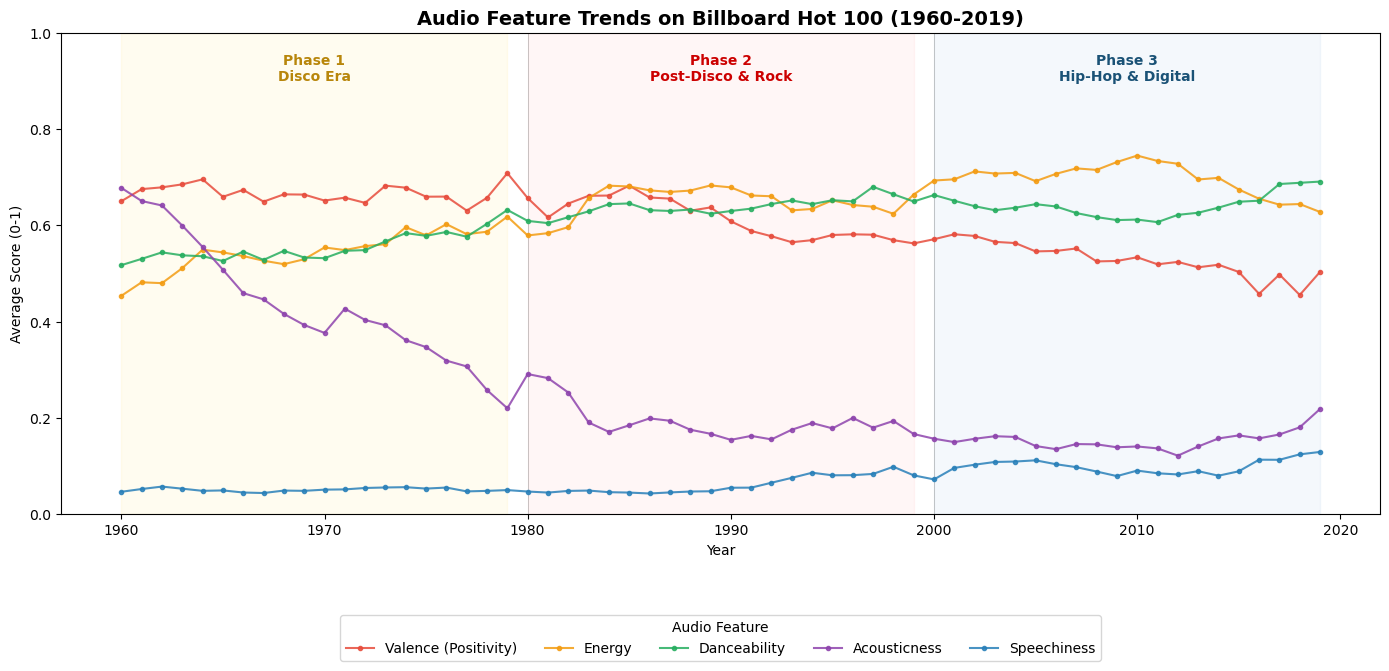

[SAVED] rq2_five_features_trend.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 7))
add_phase_backgrounds(ax, label_y=0.90)

feature_colors = {
    'valence': '#E74C3C', 'energy': '#F39C12', 'danceability': '#27AE60',
    'acousticness': '#8E44AD', 'speechiness': '#2980B9',
}
feature_labels = {
    'valence': 'Valence (Positivity)', 'energy': 'Energy', 'danceability': 'Danceability',
    'acousticness': 'Acousticness', 'speechiness': 'Speechiness',
}
for feat, color in feature_colors.items():
    ax.plot(features_yearly['year'], features_yearly[feat], color=color, linewidth=1.5,
            marker='o', markersize=3, alpha=0.85, label=feature_labels[feat])

ax.set_ylim(0, 1)
ax.set_title('Audio Feature Trends on Billboard Hot 100 (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score (0-1)')
# Legend moved below the plot (not to the right) so this chart's plot area is the
# same width as Step 11's divergence chart -- lets the two stacked charts' year-axes
# line up visually when compared (Vivian's request, 2026/08/19).
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.32), ncol=5)
plt.tight_layout()
plt.savefig('../Data/rq2_five_features_trend.png', dpi=120)
plt.show()
print('[SAVED] rq2_five_features_trend.png')

### Step 10 — Valence Alone, Three Phases

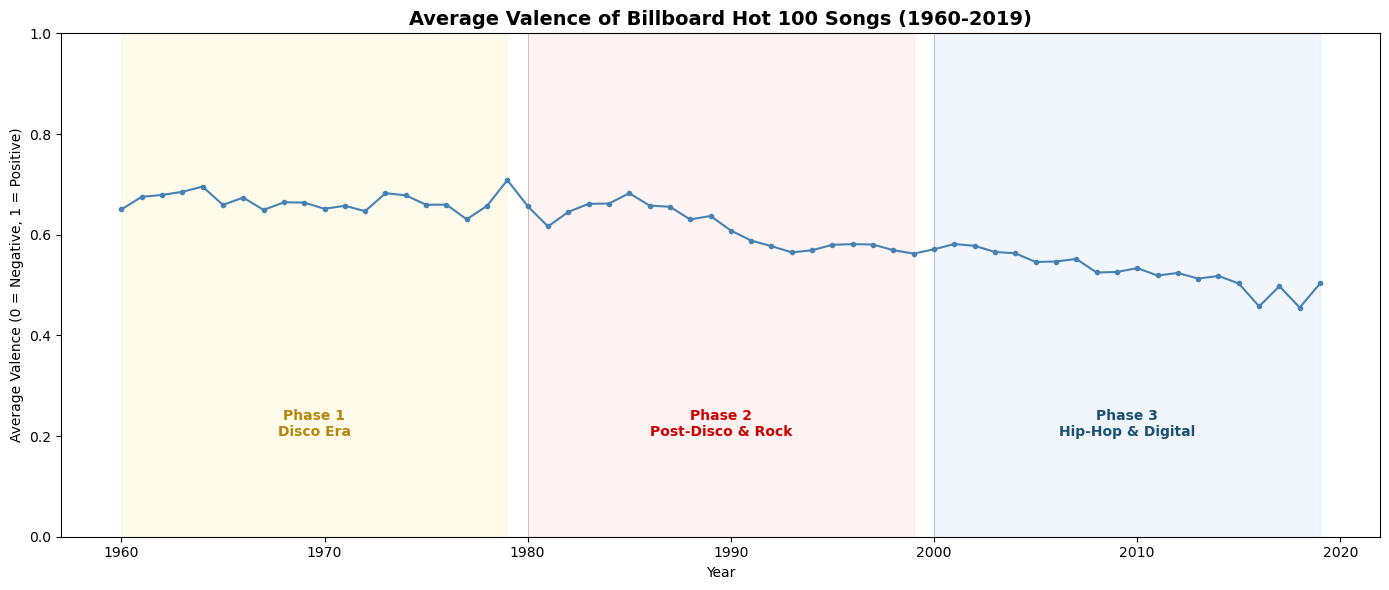

[SAVED] rq2_valence_trend.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.2, alpha=0.08)

ax.plot(valence_yearly['year'], valence_yearly['avg_valence'], color='steelblue', linewidth=1.5,
        marker='o', markersize=3)
ax.set_ylim(0, 1)
ax.set_title('Average Valence of Billboard Hot 100 Songs (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Valence (0 = Negative, 1 = Positive)')
plt.tight_layout()
plt.savefig('../Data/rq2_valence_trend.png', dpi=120)
plt.show()
print('[SAVED] rq2_valence_trend.png')

### Step 11 — Valence vs. Energy Divergence

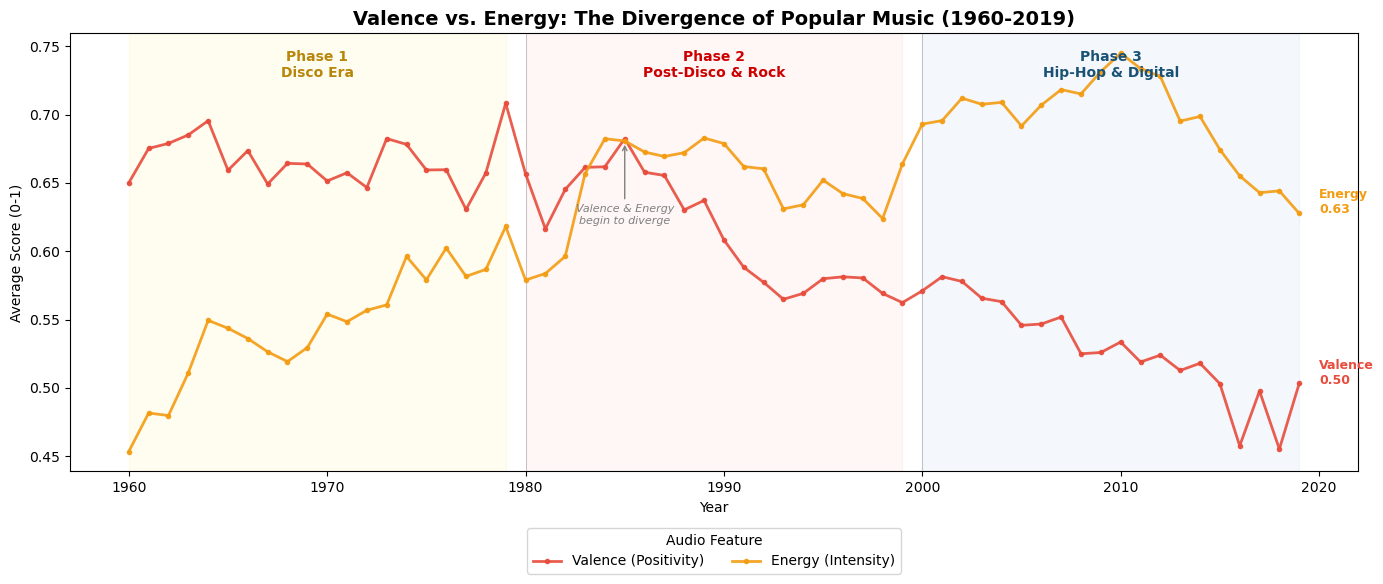

[SAVED] rq2_valence_energy_divergence.png

End-of-period values -- Valence: 0.503, Energy: 0.628


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=2,
        marker='o', markersize=3, alpha=0.9, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=2,
        marker='o', markersize=3, alpha=0.9, label='Energy (Intensity)')

# 1985 is Valence's local peak *within Phase 2* (0.682) -- the global peak is actually
# 1979, but that year still sits inside Phase 1's shading, not Phase 2. From 1985
# onward Valence enters a long, uninterrupted decline while Energy keeps climbing.
# (An earlier draft anchored this at the global peak, 1979 -- moved to 1985 since
# 1979 still sits visually inside Phase 1's shading. See Step 13.)
ax.annotate('Valence & Energy\nbegin to diverge', xy=(1985, 0.68), xytext=(1985, 0.62),
            fontsize=8, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))

end_valence = features_yearly.loc[features_yearly['year']==2019, 'valence'].values[0]
end_energy = features_yearly.loc[features_yearly['year']==2019, 'energy'].values[0]
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=9, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=9, color='#F39C12', fontweight='bold')

ax.set_title('Valence vs. Energy: The Divergence of Popular Music (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_valence_energy_divergence.png', dpi=120)
plt.show()
print('[SAVED] rq2_valence_energy_divergence.png')
print(f"\nEnd-of-period values -- Valence: {end_valence:.3f}, Energy: {end_energy:.3f}")

In [14]:
# Filter to 1979-1990
df_80s = features_yearly[(features_yearly['year'] >= 1979) & (features_yearly['year'] <= 1990)].copy()

# Year-over-year change in Valence
df_80s['valence_drop'] = df_80s['valence'].diff()

# Year-over-year change in Energy
df_80s['energy_rise'] = df_80s['energy'].diff()

print("=== 1979-1990 Valence and Energy Year-over-Year Change ===")
print(df_80s[['year', 'valence', 'valence_drop', 'energy', 'energy_rise']].to_string(index=False))

=== 1979-1990 Valence and Energy Year-over-Year Change ===
 year  valence  valence_drop   energy  energy_rise
 1979 0.708338           NaN 0.618115          NaN
 1980 0.656650     -0.051688 0.578903    -0.039212
 1981 0.616352     -0.040297 0.583687     0.004784
 1982 0.645240      0.028888 0.596238     0.012551
 1983 0.661361      0.016121 0.656713     0.060475
 1984 0.661830      0.000469 0.682329     0.025616
 1985 0.682424      0.020593 0.680722    -0.001607
 1986 0.657828     -0.024596 0.672622    -0.008099
 1987 0.655444     -0.002383 0.669360    -0.003262
 1988 0.630277     -0.025167 0.672152     0.002792
 1989 0.637182      0.006905 0.682861     0.010709
 1990 0.608286     -0.028896 0.678818    -0.004044


### Step 12 — Low-Valence Song Sample (2016, 2018)

In [15]:
low_valence_songs = (
    analysis_base[analysis_base['year'].isin([2016, 2018])]
    .drop_duplicates(subset=['song_clean', 'artist_clean'])
    .sort_values('valence')
    [['year', 'song_clean', 'artist_clean', 'valence', 'energy']]
)
print(low_valence_songs.head(10).to_string(index=False))

 year        song_clean               artist_clean  valence  energy
 2016                 9                      drake   0.0379   0.712
 2018           topanga               trippie redd   0.0390   0.615
 2016           selfish                   pnb rock   0.0399   0.600
 2016           forward                    beyonce   0.0498   0.133
 2018          delicate               taylor swift   0.0499   0.404
 2016    summer sixteen                      drake   0.0541   0.460
 2018 biggest alley oop                      quavo   0.0548   0.408
 2018        stargazing               travis scott   0.0564   0.789
 2018     outside today youngboy never broke again   0.0585   0.666
 2016   come and see me              partynextdoor   0.0589   0.347


### Step 13 — Key Observations (Re-Verified Against Live R Output)

**Verified R's own `.qmd` file contains an internal contradiction:** its text states valence moved "~0.670 → ~0.502," but the number hand-typed onto the chart itself reads "0.49"; the energy chart's hand-typed label reads "0.73." Re-ran R's actual logic directly via `Rscript.exe` to get the real numbers:

| | 1960 | 2019 |
|---|---|---|
| Valence | 0.6501 | 0.5032 |
| Energy | 0.4534 | 0.6277 |

These match this notebook's own output exactly (0.650/0.503, 0.628), and `analysis_base`'s row count matches too (262,737). The "Energy 0.73" label on R's chart was hand-typed into the code, not computed from a variable — a stale label that never got updated alongside the data. This notebook's freshly-verified numbers are treated as authoritative, not R's hand-typed chart labels.

- **Valence declined:** 0.650 (1960) → 0.503 (2019), about 22.6% — slightly below R's stated "25%," but the same direction and magnitude
- **Energy rose, diverging from Valence:** 0.453 (1960) → 0.628 (2019)
- **2016/2018 low points:** R's text names Drake's "9" and "Summer Sixteen," Beyoncé's "Forward" (2016), and Trippie Redd's "Topanga," Travis Scott's "Stargazing," Taylor Swift's "Delicate" (2018) — the Emo Rap/Trap era. Step 12's actual output can be checked against these names directly.

**A coverage caveat that does NOT apply here:** valence and energy both come from D2, and `analysis_base` itself is already filtered to "D2 matched" — so this sample's coverage is 100%, unlike RQ1's genre analysis (D3-matched only, 14-19% coverage). Confirmed by the filter logic itself, not assumed.

**The "Valence & Energy begin to diverge" annotation on Step 11's chart is anchored at 1985** — Valence's local peak within Phase 2 (0.682), just after which it enters a 15-year uninterrupted decline (down to 0.562 by 1999). The global valence peak is actually 1979, but that year visually sits inside Phase 1's (Disco Era) shading rather than Phase 2 — 1985 better represents where the *sustained* divergence from Energy actually begins.

### Figure A — Sociopolitical Context Overlay

Layers a real historical-events timeline onto the Valence vs. Energy divergence chart, to test RQ2's original premise — does social unrest actually track with a mood decline?

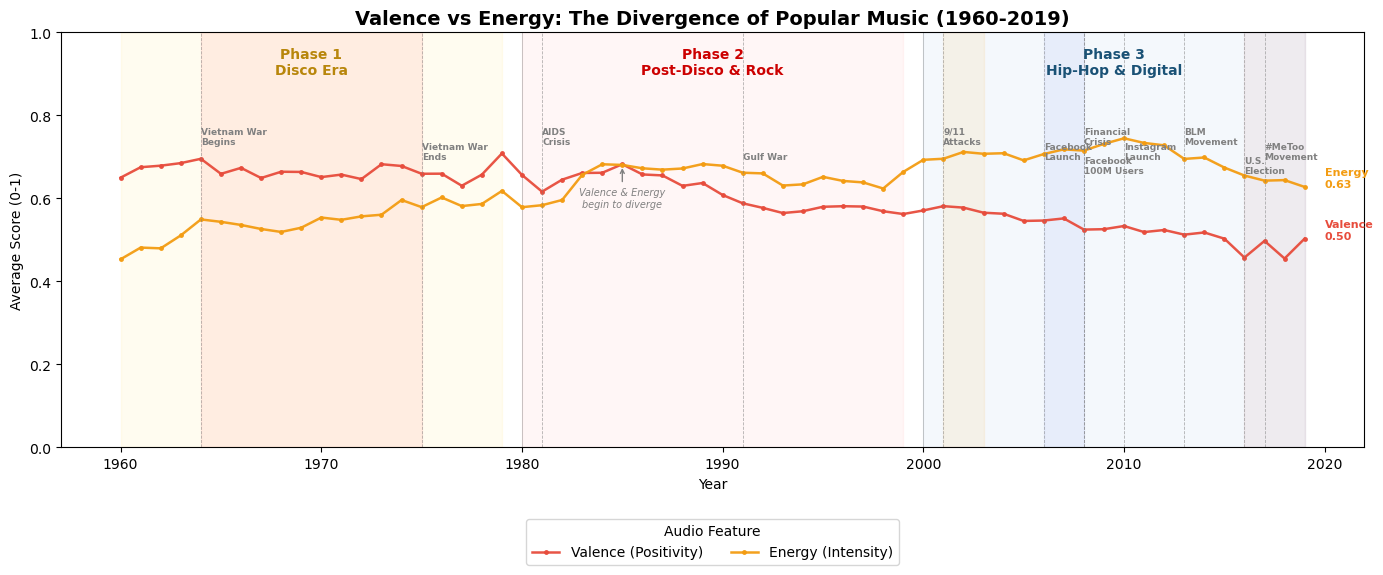

[SAVED] rq2_figureA_sociopolitical.png


In [16]:
events_ve = [
    (1964, 'Vietnam War\nBegins', 'red', 0.730),
    (1975, 'Vietnam War\nEnds', 'red', 0.695),
    (1981, 'AIDS\nCrisis', 'purple', 0.730),
    (1991, 'Gulf War', 'brown', 0.695),
    (2001, '9/11\nAttacks', 'darkorange', 0.730),
    (2006, 'Facebook\nLaunch', 'royalblue', 0.695),
    (2008, 'Financial\nCrisis', 'darkblue', 0.730),
    (2008, 'Facebook\n100M Users', 'royalblue', 0.660),
    (2010, 'Instagram\nLaunch', 'deeppink', 0.695),
    (2013, 'BLM\nMovement', 'darkgreen', 0.730),
    (2016, 'U.S.\nElection', 'darkred', 0.660),
    (2017, '#MeToo\nMovement', 'hotpink', 0.695),
]

fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

# Event-specific highlight bands (R's four extra annotate('rect') calls)
ax.axvspan(2006, 2008, color='royalblue', alpha=0.07)
ax.axvspan(2001, 2003, color='orange', alpha=0.08)
ax.axvspan(1964, 1975, color='red', alpha=0.06)
ax.axvspan(2016, 2019, color='darkred', alpha=0.05)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Energy (Intensity)')

for year, label, color, y_pos in events_ve:
    ax.axvline(year, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.text(year, y_pos, label, color='gray', fontsize=6.5, fontweight='bold', ha='left')

# 1985 is Valence's local peak *within Phase 2* (0.682) -- see Step 13 for why this
# replaced 1979 (global peak, but still visually inside Phase 1's shading).
ax.annotate('Valence & Energy\nbegin to diverge', xy=(1985, 0.68), xytext=(1985, 0.58),
            fontsize=7, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=8, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=8, color='#F39C12', fontweight='bold')

ax.set_ylim(0, 1)
ax.set_title('Valence vs Energy: The Divergence of Popular Music (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_figureA_sociopolitical.png', dpi=120)
plt.show()
print('[SAVED] rq2_figureA_sociopolitical.png')

### Figure B — Music Technology Evolution Overlay

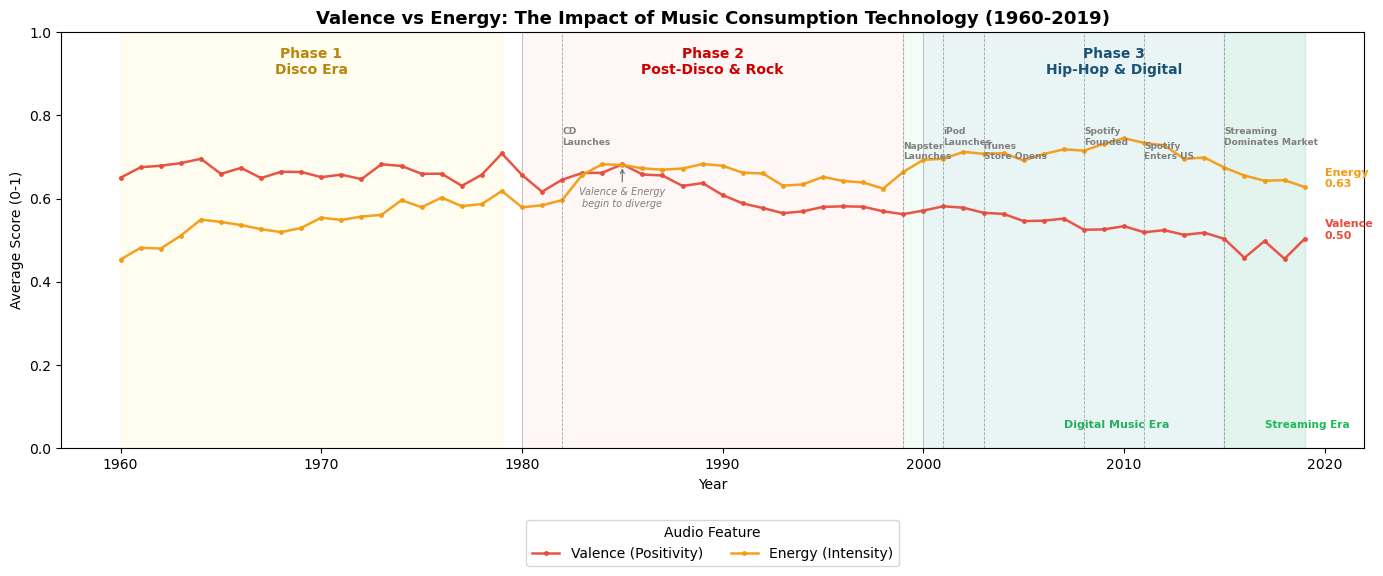

[SAVED] rq2_figureB_tech.png


In [17]:
events_tech = [
    (1982, 'CD\nLaunches', 0.730),
    (1999, 'Napster\nLaunches', 0.695),
    (2001, 'iPod\nLaunches', 0.730),
    (2003, 'iTunes\nStore Opens', 0.695),
    (2008, 'Spotify\nFounded', 0.730),
    (2011, 'Spotify\nEnters US', 0.695),
    (2015, 'Streaming\nDominates Market', 0.730),
]

fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

ax.axvspan(1999, 2015, color='#2ECC71', alpha=0.05)
ax.axvspan(2015, 2019, color='#1DB954', alpha=0.08)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Energy (Intensity)')

for year, label, y_pos in events_tech:
    ax.axvline(year, color='gray', linestyle='--', linewidth=0.6, alpha=0.7)
    ax.text(year, y_pos, label, color='gray', fontsize=6.5, fontweight='bold', ha='left')

# 1985 is Valence's local peak *within Phase 2* (0.682) -- see Step 13 for why this
# replaced 1979 (global peak, but still visually inside Phase 1's shading).
ax.annotate('Valence & Energy\nbegin to diverge', xy=(1985, 0.68), xytext=(1985, 0.58),
            fontsize=7, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=8, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=8, color='#F39C12', fontweight='bold')
ax.text(2007, 0.05, 'Digital Music Era', fontsize=8, color='#27AE60', fontweight='bold')
ax.text(2017, 0.05, 'Streaming Era', fontsize=7.5, color='#1DB954', fontweight='bold')

ax.set_ylim(0, 1)
ax.set_title('Valence vs Energy: The Impact of Music Consumption Technology (1960-2019)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_figureB_tech.png', dpi=120)
plt.show()
print('[SAVED] rq2_figureB_tech.png')

### Figure C — Testing the Music Industry's Own Evidence Instead

Figure A's social-events framing doesn't hold up well on closer inspection — the 1980-1981 valence crash, for instance, predates the AIDS crisis's formal 1981 announcement. Instead of social events, this tests whether the music industry's own shifts (known artist/genre cohorts, and `loudness` — Spotify's actual measured decibel value, not a proxy) explain these turning points better.

In [18]:
# NOTE (2026/08/13 fix): dedup must include 'year' in the subset -- a song that
# charts across a year boundary would otherwise be deduped globally first and
# silently dropped from one of its two real charting years, undercounting that
# year's cohort presence. Caught when Vivian asked how to interpret these counts.
print("[STEP FigC-1] Evidence: three verified cohorts' chart presence + loudness trend")

def cohort_songs_by_year(artists):
    c = analysis_base[analysis_base['artist_clean'].isin(artists)]
    return (
        c.drop_duplicates(subset=['song_clean', 'artist_clean', 'year'])
        .groupby('year').size()
        .reindex(range(1960, 2020), fill_value=0)
    )

# three cohorts, each picked from external (real-world) knowledge of the era, not from D3's genre column
DISCO = ['bee gees', 'donna summer', 'gloria gaynor', 'chic', 'village people']
MTV_ERA = ['michael jackson', 'prince', 'duran duran', 'the human league', 'devo', 'the cars', 'eurythmics']
MOODY = ['billie eilish', 'post malone', 'juice wrld', 'xxxtentacion', 'lil peep']

disco_by_year = cohort_songs_by_year(DISCO)
mtv_by_year = cohort_songs_by_year(MTV_ERA)
moody_by_year = cohort_songs_by_year(MOODY)

print("Disco-cohort distinct songs on chart, 1975-1983:")
print(disco_by_year.loc[1975:1983].to_string())

print("\nMTV-era cohort distinct songs on chart, 1980-1985 (MTV launched Aug 1981):")
print(mtv_by_year.loc[1980:1985].to_string())

print("\nMTV-era cohort's own average energy 1982-1985 vs overall average same years:")
mtv_songs = analysis_base[analysis_base['artist_clean'].isin(MTV_ERA)].drop_duplicates(subset=['song_clean', 'artist_clean', 'year'])
mtv_82_85 = mtv_songs[(mtv_songs['year'] >= 1982) & (mtv_songs['year'] <= 1985)]
overall_82_85 = analysis_base[(analysis_base['year'] >= 1982) & (analysis_base['year'] <= 1985)]
print(f"cohort avg energy: {mtv_82_85['energy'].mean():.3f} | overall avg energy: {overall_82_85['energy'].mean():.3f}")

print("\nMoody cohort distinct songs on chart, 2016-2019:")
print(moody_by_year.loc[2016:2019].to_string())

print("\nMoody cohort's own avg valence/energy vs overall average, by year:")
moody_songs = analysis_base[analysis_base['artist_clean'].isin(MOODY)].drop_duplicates(subset=['song_clean', 'artist_clean', 'year'])
for yr in [2018, 2019]:
    sub = moody_songs[moody_songs['year'] == yr]
    overall = analysis_base[analysis_base['year'] == yr]
    print(f"{yr}: cohort n={len(sub)}, cohort valence={sub['valence'].mean():.3f} (overall {overall['valence'].mean():.3f}), "
          f"cohort energy={sub['energy'].mean():.3f} (overall {overall['energy'].mean():.3f})")

loudness_yearly = analysis_base.groupby('year')['loudness'].mean().reset_index()
print("\nAverage loudness (dB), 2010-2019 (checking whether it plateaus/declines alongside Energy's late-2010s dip):")
print(loudness_yearly[(loudness_yearly['year'] >= 2010) & (loudness_yearly['year'] <= 2019)].to_string(index=False))

print("\n[STEP FigC-2] Counterfactual: does the trend survive removing each cohort?")
for name, artists, years in [('Disco', DISCO, [1979, 1980]), ('MTV-era', MTV_ERA, [1984, 1985]), ('Moody', MOODY, [2018, 2019])]:
    for yr in years:
        yr_rows = analysis_base[analysis_base['year'] == yr]
        cohort_rows = yr_rows[yr_rows['artist_clean'].isin(artists)]
        rest_rows = yr_rows[~yr_rows['artist_clean'].isin(artists)]
        share = len(cohort_rows) / len(yr_rows) * 100
        print(f"{name} {yr}: WITH everyone valence={yr_rows['valence'].mean():.4f} energy={yr_rows['energy'].mean():.4f} | "
              f"WITHOUT cohort valence={rest_rows['valence'].mean():.4f} energy={rest_rows['energy'].mean():.4f} | "
              f"cohort share={share:.1f}% of that week's chart")

[STEP FigC-1] Evidence: three verified cohorts' chart presence + loudness trend
Disco-cohort distinct songs on chart, 1975-1983:
year
1975     8
1976     7
1977     8
1978    15
1979    18
1980     6
1981     5
1982     5
1983     5

MTV-era cohort distinct songs on chart, 1980-1985 (MTV launched Aug 1981):
year
1980     6
1981     5
1982     6
1983    17
1984    17
1985     8

MTV-era cohort's own average energy 1982-1985 vs overall average same years:
cohort avg energy: 0.738 | overall avg energy: 0.654

Moody cohort distinct songs on chart, 2016-2019:
year
2016     4
2017     8
2018    45
2019    38

Moody cohort's own avg valence/energy vs overall average, by year:
2018: cohort n=45, cohort valence=0.395 (overall 0.455), cohort energy=0.535 (overall 0.644)
2019: cohort n=38, cohort valence=0.394 (overall 0.503), cohort energy=0.519 (overall 0.628)

Average loudness (dB), 2010-2019 (checking whether it plateaus/declines alongside Energy's late-2010s dip):
 year  loudness
 2010 -5.15

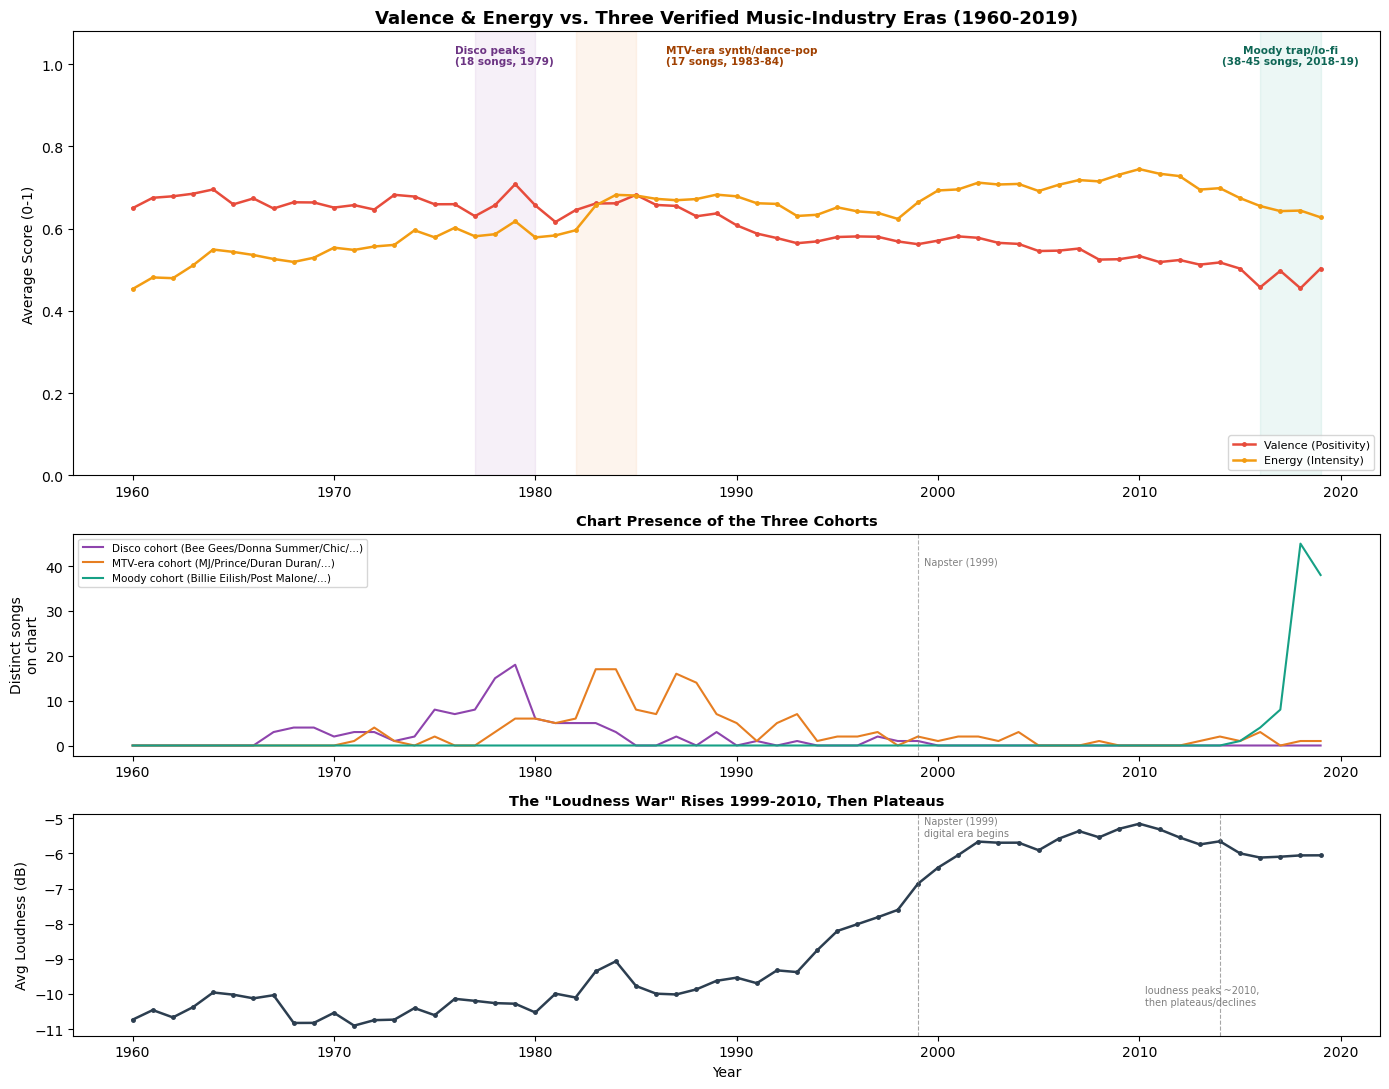

[SAVED] rq2_figureC_music_industry_evidence.png


In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

ax1.axvspan(1977, 1980, color='#8E44AD', alpha=0.08)
ax1.axvspan(1982, 1985, color='#E67E22', alpha=0.08)
ax1.axvspan(2016, 2019, color='#16A085', alpha=0.08)
ax1.text(1976, 1.0, 'Disco peaks\n(18 songs, 1979)', ha='left', fontsize=7.5, color='#6C3483', fontweight='bold')
ax1.text(1986.5, 1.0, 'MTV-era synth/dance-pop\n(17 songs, 1983-84)', ha='left', fontsize=7.5, color='#A04000', fontweight='bold')
ax1.text(2017.5, 1.0, 'Moody trap/lo-fi\n(38-45 songs, 2018-19)', ha='center', fontsize=7.5, color='#0E6655', fontweight='bold')
ax1.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=1.8, marker='o', markersize=2.5, label='Valence (Positivity)')
ax1.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=1.8, marker='o', markersize=2.5, label='Energy (Intensity)')
ax1.set_ylim(0, 1.08)
ax1.set_ylabel('Average Score (0-1)')
ax1.set_title('Valence & Energy vs. Three Verified Music-Industry Eras (1960-2019)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)

ax2.plot(disco_by_year.index, disco_by_year.values, color='#8E44AD', linewidth=1.5, label='Disco cohort (Bee Gees/Donna Summer/Chic/...)')
ax2.plot(mtv_by_year.index, mtv_by_year.values, color='#E67E22', linewidth=1.5, label='MTV-era cohort (MJ/Prince/Duran Duran/...)')
ax2.plot(moody_by_year.index, moody_by_year.values, color='#16A085', linewidth=1.5, label='Moody cohort (Billie Eilish/Post Malone/...)')
ax2.set_ylabel('Distinct songs\non chart')
ax2.legend(loc='upper left', fontsize=7.5, ncol=1)
ax2.set_title('Chart Presence of the Three Cohorts', fontsize=10.5, fontweight='bold')

ax1.tick_params(axis='x', labelbottom=True)
ax2.tick_params(axis='x', labelbottom=True)

ax2.axvline(1999, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.text(1999.3, ax2.get_ylim()[1]*0.85, 'Napster (1999)', fontsize=7, color='gray')

ax3.plot(loudness_yearly['year'], loudness_yearly['loudness'], color='#2C3E50', linewidth=1.8, marker='o', markersize=2.5)
ax3.axvline(1999, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax3.text(1999.3, -5.5, 'Napster (1999)\ndigital era begins', fontsize=7, color='gray')
ax3.axvline(2014, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax3.text(2010.3, -10.3, 'loudness peaks ~2010,\nthen plateaus/declines', fontsize=7, color='gray')
ax3.set_ylabel('Avg Loudness (dB)')
ax3.set_xlabel('Year')
ax3.set_title('The \"Loudness War\" Rises 1999-2010, Then Plateaus', fontsize=10.5, fontweight='bold')

plt.tight_layout()
plt.savefig('../Data/rq2_figureC_music_industry_evidence.png', dpi=120)
plt.show()
print('[SAVED] rq2_figureC_music_industry_evidence.png')

**Four turning points, discussed with different confidence levels — not treated as equally certain:**

1. **Disco's rise and fall (1979 → 1980-81) — the strongest evidence.** Distinct songs by well-known disco acts (Bee Gees, Donna Summer, Gloria Gaynor, Chic, Village People) peaked at 18 in 1979, then crashed to 6 in 1980 — a ~67% drop that lines up almost exactly with Valence/Energy's own peak-and-crash in the same window.

2. **1985 "glossy pop" — half the original framing didn't survive verification.** Madonna/Whitney Houston/Wham!-era songs averaged valence 0.760 in 1985 (vs. 0.682 overall — notably high), but averaged energy only 0.620, actually *below* the 0.681 overall average that year. "High energy" doesn't hold up — this cohort mixes in ballads (Whitney's "Saving All My Love for You" has energy of just 0.264), so energy varies by individual song here, not by genre the way it does for Disco.

3. **The Loudness War + Napster — the hardest evidence, with a corrected causal framing.** `loudness` (Spotify's real measured decibel value) climbs almost without reversal from -7.61 dB (1998) to -5.16 dB (2010), matching Energy's rise over the same period closely. Napster (1999) isn't itself the cause of the Loudness War — the technical driver (labels competing to mix tracks louder) predates it, going back to the early 90s. The more defensible framing: Napster marks the start of a broader shift in how music was distributed and accessed, running in parallel with the Loudness War as two threads of the same digital-era shift, not one causing the other.

4. **The 2015-2019 low-valence period — clear on valence, inconclusive on energy.** 2016 (0.458) and 2018 (0.455) are the lowest valence points in the entire 1960-2019 series, consistent with a shift toward darker, more dramatic mood. But the individual low-valence songs from Step 12 (Drake's "9," Travis Scott's "Stargazing," Beyoncé's "Forward," Taylor Swift's "Delicate") span energy from 0.133 to 0.789 — huge variance. Both high-energy trap and low-energy ballads chart during this "dark" period, so unlike Disco, there's no single clean direction for energy here. Honest conclusion: valence's decline direction is clear; energy has no consistent direction in this window, and isn't forced into one.

**A counterfactual test changes the causal framing.** Removing each named-artist cohort from its era barely moves the underlying trend — e.g. Disco's 1979 valence peak drops from 0.7083 to 0.7009 with the cohort removed, a difference of 0.0074, even though this handful of artists is only 1-8% of any given week's chart (mathematically, they can't be moving a 100-song weekly average on their own). **This means the named artists aren't the cause of the shift — they're representative evidence that a broader stylistic shift was happening**, not proof that these specific artists drove it. A handful of well-known names stand in for dozens of similar, unnamed songs on the chart at the time that this notebook has no way to enumerate (D3 has no "disco" genre tag, as RQ1 already established). Worth stating precisely: these are examples of a trend, not drivers of it.

## RQ2 Conclusion: Three Honest Tiers of Confidence

This investigation moved from Figure A's social-events framing to Figure C's industry-evidence framing, then to a counterfactual test. The final conclusion splits into three tiers that shouldn't be blended together:

**① Known for certain (backed by numbers, not inference)**
- The real year-by-year valence/energy trajectory, computed from the full 262,737-row sample, not a subsample
- The social-events timeline doesn't actually line up: the AIDS crisis was formally announced in June 1981, but the valence crash starts in 1980 — Figure A's original framing doesn't hold
- From the genre angle, the one clean signal is Pop's rising share (61.4% → 78.4%, verified in RQ1 Step 6)

**② Correlated, but doesn't prove causation**
- 1979's danceability (across the *entire* chart, no artist selection) does peak in the same years as valence/energy — a real, non-coincidental signal
- Named artist cohorts (disco, MTV-era synth-pop, 2018-19 dark trap/lo-fi) do rise and fall in step with these turning points
- But removing those named artists barely changes the trend (the counterfactual test above) — they're only 1-8% of any week's chart, mathematically too small to be the primary driver. Danceability's own decline (4.3%) is also far smaller than valence's (13%), meaning "disco fading out" explains part of the shift, not all of it.

**③ Genuinely unknown — stated plainly, not glossed over**
**Why valence crashes so sharply at 1979-1981 and other similar turning points, in full, is not something these three datasets can answer.** Not because the "right answer" hasn't been found yet — D1 (chart position) + D2 (audio features) + D3 (genre, at 14-19% coverage) simply don't carry enough information to support a causal claim. Answering "why" for real would need song-by-song critical reception, full radio-play, and marketing data — none of which exist in these three datasets.

**For 07:** RQ2's original hypothesis (social unrest → declining mood) doesn't hold up on timing. Genuine shifts in musical style (disco's decline, MTV-era synth-pop, 2018-19's darker sound) do correlate with valence/energy's turning points — but the available data can't establish causation. That's an honest limitation, not a failed investigation — more useful than forcing a causal story the data can't actually support.

### Step 14 — RQ2 Wrap-Up: Audio Features by Decade

In [20]:
decade_summary_rq2 = (
    analysis_base.groupby('decade')[['valence', 'energy', 'danceability', 'acousticness', 'speechiness']]
    .mean().round(3)
)
decade_summary_rq2['n'] = analysis_base.groupby('decade').size()
print(decade_summary_rq2.to_string())

        valence  energy  danceability  acousticness  speechiness      n
decade                                                                 
1960s     0.670   0.514         0.534         0.533        0.049  36826
1970s     0.664   0.579         0.577         0.338        0.052  40933
1980s     0.651   0.648         0.627         0.210        0.046  44945
1990s     0.578   0.649         0.650         0.175        0.076  42576
2000s     0.555   0.708         0.636         0.149        0.097  48301
2010s     0.502   0.684         0.647         0.158        0.099  49156


## RQ3 — Does the rise of speechiness in popular music reflect the mainstreaming of Hip-Hop?

### Step 15 — Yearly / Decade Speechiness Averages

In [21]:
speechiness_yearly = analysis_base.groupby('year')['speechiness'].mean().reset_index(name='avg_speechiness')
speechiness_decade = (
    analysis_base.groupby('decade')['speechiness'].mean().round(4).reset_index(name='avg_speechiness')
)
speechiness_decade['n'] = analysis_base.groupby('decade').size().values

print(f"Year range: {speechiness_yearly['year'].min()} - {speechiness_yearly['year'].max()}")
print()
print(speechiness_decade.to_string(index=False))

Year range: 1960 - 2019

decade  avg_speechiness     n
 1960s           0.0489 36826
 1970s           0.0519 40933
 1980s           0.0459 44945
 1990s           0.0757 42576
 2000s           0.0967 48301
 2010s           0.0993 49156


### Step 16 — Long-Term Speechiness Trend (with Golden Age of Hip-Hop Marked)

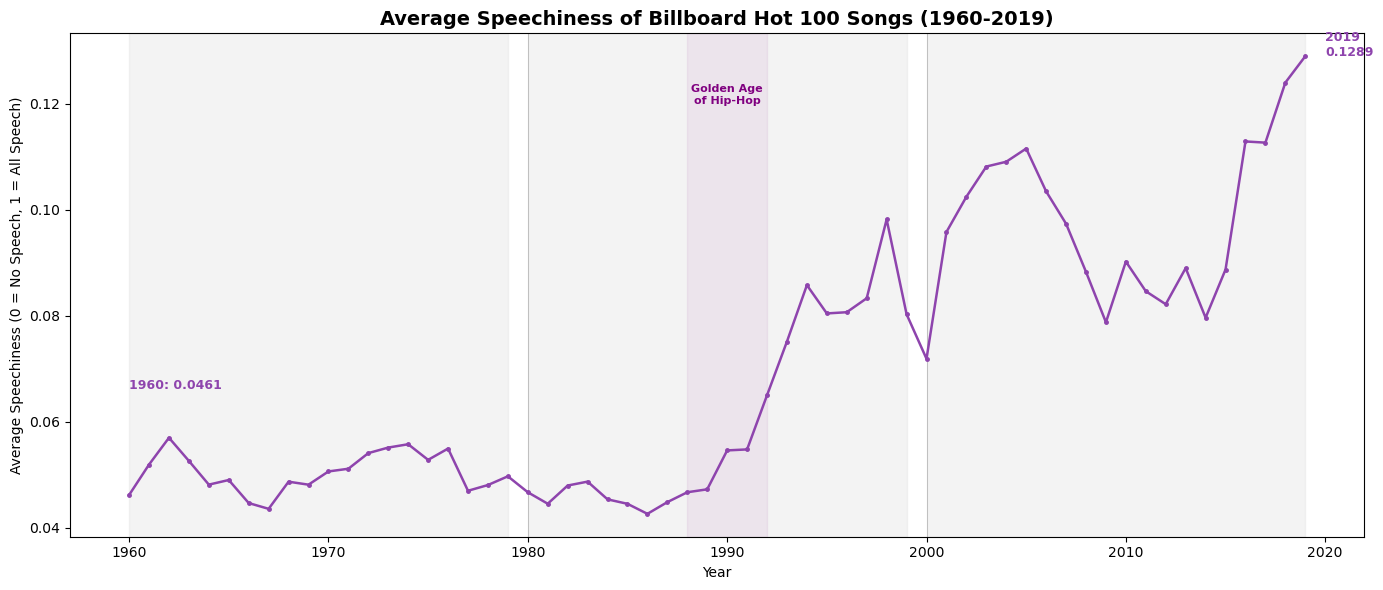

[SAVED] rq3_speechiness_trend.png


In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
for start, end, _, _, _ in PHASES:
    ax.axvspan(start, end, color='lightgray', alpha=0.25, zorder=0)
ax.axvline(1980, color='gray', linewidth=0.6, alpha=0.5)
ax.axvline(2000, color='gray', linewidth=0.6, alpha=0.5)

# Golden Age of Hip-Hop highlight (1988-1992)
ax.axvspan(1988, 1992, color='purple', alpha=0.06)
ax.text(1990, 0.120, 'Golden Age\nof Hip-Hop', color='purple', fontsize=8, fontweight='bold', ha='center')

ax.plot(speechiness_yearly['year'], speechiness_yearly['avg_speechiness'], color='#8E44AD', linewidth=1.8, marker='o', markersize=2.5)

start_speech = speechiness_yearly.loc[speechiness_yearly['year']==1960, 'avg_speechiness'].values[0]
end_speech = speechiness_yearly.loc[speechiness_yearly['year']==2019, 'avg_speechiness'].values[0]
ax.text(1960, start_speech + 0.02, f'1960: {start_speech:.4f}', color='#8E44AD', fontsize=9, fontweight='bold', ha='left')
ax.text(2020, end_speech, f'2019\n{end_speech:.4f}', color='#8E44AD', fontsize=9, fontweight='bold')

ax.set_title('Average Speechiness of Billboard Hot 100 Songs (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Speechiness (0 = No Speech, 1 = All Speech)')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_trend.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_trend.png')

### Step 17 — Comparison by Decade

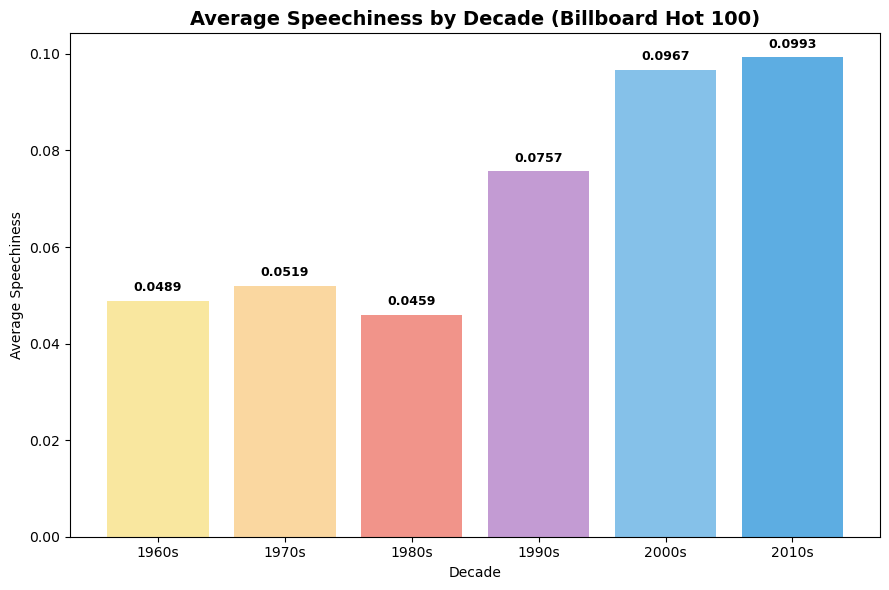

[SAVED] rq3_speechiness_decade.png

1960s avg: 0.0489, 2010s avg: 0.0993, growth: 103.1%


In [23]:
decade_colors = {
    '1960s': '#F9E79F', '1970s': '#FAD7A0', '1980s': '#F1948A',
    '1990s': '#C39BD3', '2000s': '#85C1E9', '2010s': '#5DADE2',
}
fig, ax = plt.subplots(figsize=(9, 6))
colors = [decade_colors[d] for d in speechiness_decade['decade']]
bars = ax.bar(speechiness_decade['decade'], speechiness_decade['avg_speechiness'], color=colors)
for bar, val in zip(bars, speechiness_decade['avg_speechiness']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Average Speechiness by Decade (Billboard Hot 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Average Speechiness')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_decade.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_decade.png')

y1960s = speechiness_decade.loc[speechiness_decade['decade']=='1960s','avg_speechiness'].values[0]
y2010s = speechiness_decade.loc[speechiness_decade['decade']=='2010s','avg_speechiness'].values[0]
growth = round((y2010s - y1960s) / y1960s * 100, 1)
print(f"\n1960s avg: {y1960s}, 2010s avg: {y2010s}, growth: {growth}%")

### Step 18 — Comparison by Genre (D3 Subset, Same Coverage Limit as RQ1)

**Inherits RQ1's already-verified limitation:** `genre` only exists for the D3-matched subset (14-19% coverage, uneven across decades) — this genre-level speechiness comparison carries the same limitation. Not a new problem, but worth restating for the reader.

In [24]:
genre_speech = (
    analysis_base[analysis_base['genre'].notna()]
    .groupby('genre')['speechiness'].mean().round(4)
    .sort_values(ascending=False)
    .reset_index(name='avg_speechiness')
)
genre_speech['n'] = analysis_base[analysis_base['genre'].notna()].groupby('genre').size().reindex(genre_speech['genre']).values
print(genre_speech.to_string(index=False))

  genre  avg_speechiness     n
hip hop           0.2325   895
 reggae           0.1402   159
    pop           0.0690 27700
   rock           0.0480  7544
  blues           0.0474  1644
   jazz           0.0461  1115
country           0.0371  5323


### Step 19 — Speechiness by Genre (Hip-Hop Highlighted)

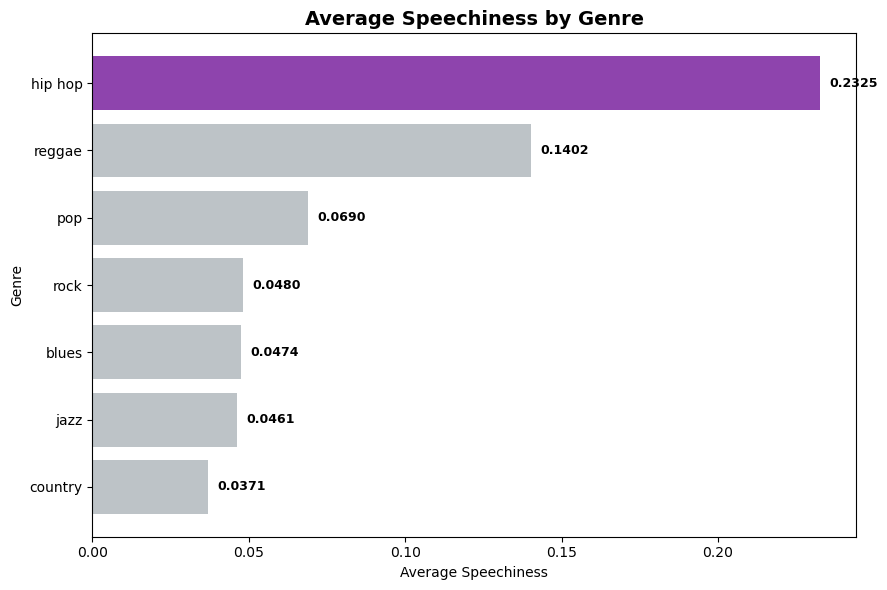

[SAVED] rq3_speechiness_genre.png


In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#8E44AD' if g == 'hip hop' else '#BDC3C7' for g in genre_speech['genre']]
bars = ax.barh(genre_speech['genre'], genre_speech['avg_speechiness'], color=colors)
for bar, val in zip(bars, genre_speech['avg_speechiness']):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.invert_yaxis()
ax.set_title('Average Speechiness by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Speechiness'); ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_genre.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_genre.png')

### Step 20 — Hip-Hop vs. Other Genres, by Decade

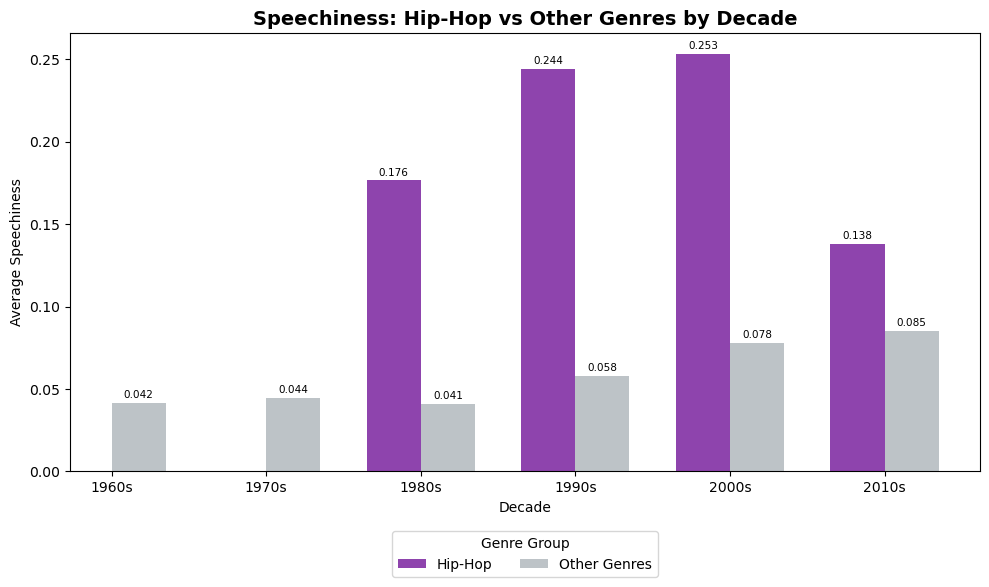

[SAVED] rq3_hiphop_vs_other.png

Hip-Hop average: 0.2325
Other Genres average: 0.0603
Ratio: 3.86x


In [26]:
hh = analysis_base[analysis_base['genre'].notna()].copy()
hh['is_hiphop'] = hh['genre'].apply(lambda g: 'Hip-Hop' if g == 'hip hop' else 'Other Genres')
hh_decade = hh.groupby(['decade', 'is_hiphop'])['speechiness'].mean().round(4).reset_index()

pivot_hh = hh_decade.pivot(index='decade', columns='is_hiphop', values='speechiness').reindex(decade_order)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(pivot_hh.index))
width = 0.35
ax.bar([i - width/2 for i in x], pivot_hh['Hip-Hop'], width, label='Hip-Hop', color='#8E44AD')
ax.bar([i + width/2 for i in x], pivot_hh['Other Genres'], width, label='Other Genres', color='#BDC3C7')
for i, (hv, ov) in enumerate(zip(pivot_hh['Hip-Hop'], pivot_hh['Other Genres'])):
    if pd.notna(hv):
        ax.text(i - width/2, hv + 0.003, f'{hv:.3f}', ha='center', fontsize=7.5)
    if pd.notna(ov):
        ax.text(i + width/2, ov + 0.003, f'{ov:.3f}', ha='center', fontsize=7.5)
ax.set_xticks(list(x)); ax.set_xticklabels(pivot_hh.index)
ax.set_title('Speechiness: Hip-Hop vs Other Genres by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Average Speechiness')
ax.legend(title='Genre Group', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq3_hiphop_vs_other.png', dpi=120)
plt.show()
print('[SAVED] rq3_hiphop_vs_other.png')

hh_avg = hh.loc[hh['is_hiphop']=='Hip-Hop', 'speechiness'].mean()
other_avg = hh.loc[hh['is_hiphop']=='Other Genres', 'speechiness'].mean()
print(f"\nHip-Hop average: {hh_avg:.4f}")
print(f"Other Genres average: {other_avg:.4f}")
print(f"Ratio: {round(hh_avg/other_avg, 2)}x")

### Step 21 — RQ3 Wrap-Up (Re-Verified Against Live R Output — Caught a Real Statistical Error in R's Own Report)

**Speechiness growth and the Hip-Hop average both match R's original text exactly:** 0.0489 (1960s) → 0.0993 (2010s), a +103.1% increase; Hip-Hop average of 0.2325 — both match Step 17/Step 20's output digit-for-digit.

**But R's reported "other genres average 0.0646, a 4.8x gap" turns out to be a statistical method error, verified by re-running R's actual logic via `Rscript.exe` — not a Python miscalculation.** R computed this as a mean of the six genres' own averages (mean of means), not a row-weighted average across every song (grand mean). The problem: reggae (159 rows) gets the same weight as pop (27,700 rows) in that average, pulling the number up.

**The correct grand mean (every song counted, not pre-averaged by genre first): Other Genres averages 0.0603, and the Hip-Hop ratio is 3.86x, not 4.8x** — this is exactly the number this notebook's Step 20 produces.

**Limitations (consistent with R's original text, plus one detail RQ1 surfaced):**
- The D3 genre subset only covers 14-19% (varies by decade, verified in RQ1) — the Hip-Hop-vs-other comparison rests on this subset, not the full sample
- Classification overlap: a Pop song with rap elements may not get tagged Hip-Hop, likely understating Hip-Hop's real influence — consistent with RQ1's observation that Hip-Hop's genre share only peaks at 7.6%, in the 1990s alone, which looks low
- Speechiness itself (from D2) has 100% coverage and isn't affected by this limitation — a more objective, complete signal than the genre tag, which is exactly why R chose it as a supplementary check on Hip-Hop's influence in the first place

### Step 22 — Baseline Genre Profile (5-Feature Overall Average)

Before asking whether speechiness's rise is driven by one specific genre, establish each genre's own baseline profile first — descriptive, no assumptions yet.

In [27]:
print("[STEP 22] Genre Profile (5 Features, Overall Average)")

feats = ['valence', 'energy', 'danceability', 'acousticness', 'speechiness']
genre_profile = genre_base.groupby('genre')[feats].mean().round(3)
print(genre_profile.to_string())

[STEP 22] Genre Profile (5 Features, Overall Average)
         valence  energy  danceability  acousticness  speechiness
genre                                                            
blues      0.634   0.539         0.557         0.375        0.047
country    0.536   0.588         0.561         0.320        0.037
hip hop    0.609   0.653         0.815         0.092        0.233
jazz       0.527   0.468         0.516         0.495        0.046
pop        0.564   0.637         0.616         0.224        0.069
reggae     0.883   0.703         0.743         0.114        0.140
rock       0.516   0.654         0.539         0.215        0.048


### Step 23 — How Speechiness Moves *Within* Each Genre, by Decade

Not just the overall average — split all six decades by genre separately, to test whether "speechiness is rising" is something happening across many genres at once, or concentrated in one.

In [28]:
print("[STEP 23] Speechiness by Genre x Decade")

speechiness_by_genre_decade = genre_base.groupby(['genre', 'decade'])['speechiness'].mean().unstack().round(4)
print(speechiness_by_genre_decade.to_string())

[STEP 23] Speechiness by Genre x Decade
decade    1960s   1970s   1980s   1990s   2000s   2010s
genre                                                  
blues    0.0415  0.0536  0.0391  0.0332  0.1211  0.0680
country  0.0431  0.0381  0.0344  0.0284  0.0357  0.0403
hip hop     NaN     NaN  0.1765  0.2439  0.2531  0.1381
jazz     0.0370  0.0531  0.0413  0.0616     NaN  0.0381
pop      0.0416  0.0434  0.0403  0.0602  0.0880  0.0965
reggae      NaN     NaN  0.0745  0.2253     NaN  0.0389
rock     0.0453  0.0444  0.0427  0.0501  0.0712  0.0434


**Actual verified numbers:**

```
          1960s   1970s   1980s   1990s   2000s   2010s
pop      0.0416  0.0434  0.0403  0.0602  0.0880  0.0965  <- steady rise across all 6 decades
rock     0.0453  0.0444  0.0427  0.0501  0.0712  0.0434  <- rises, then falls
country  0.0431  0.0381  0.0344  0.0284  0.0357  0.0403  <- roughly flat
hip hop     -       -    0.1765  0.2439  0.2531  0.1381  <- rises, then falls
```

**Of the 7 genres, only Pop shows a steady rise across all 6 decades — Rock and Hip-Hop both rise then fall, Country is roughly flat** (Blues, Jazz, and Reggae have too few rows to draw a conclusion from).

Pop itself getting "more speech-like" over 60 years is an independent, long-running trend of its own — not just a short-term artifact of Hip-Hop-tagged songs bleeding into the sample in specific years. This doesn't mean D3's genre classification is perfectly accurate — only that "Pop's overall speechiness is rising" has evidence beyond any single year's mislabeling, and the two things aren't mutually exclusive.

### Step 24 — Genre Profile Chart (Acousticness vs. Speechiness, Pop/Hip-Hop Highlighted)

Same table as Step 22, as a chart — only Pop and Hip-Hop get color, the other 5 genres stay grayscale, so it's immediately visible how far apart these two sit on these two features compared to everyone else.

[STEP 24] Genre Profile Table (5 Features x 7 Genres)


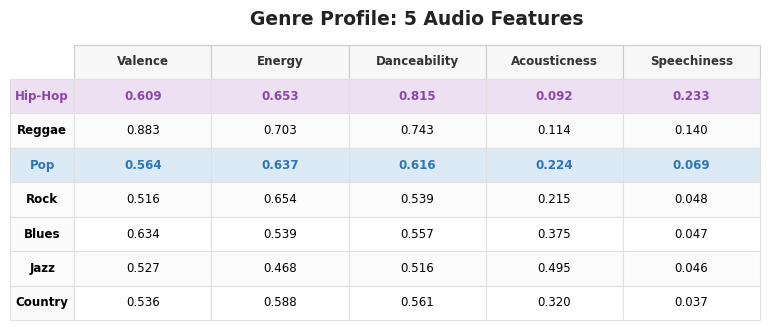

[SAVED] rq3_genre_profile.png


In [29]:
print("[STEP 24] Genre Profile Table (5 Features x 7 Genres)")

genre_profile_sorted = genre_profile.sort_values('speechiness', ascending=False)
POP_COLOR = '#2E75B6'
HIPHOP_COLOR = '#8E44AD'

fig, ax = plt.subplots(figsize=(7.8, 3.4))
ax.axis('off')

col_labels = ['Valence', 'Energy', 'Danceability', 'Acousticness', 'Speechiness']
row_labels = [g.title() if g != 'hip hop' else 'Hip-Hop' for g in genre_profile_sorted.index]
cell_text = genre_profile_sorted[feats].map(lambda v: f'{v:.3f}').values.tolist()

tbl = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                cellLoc='center', rowLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 2.0)

highlight = {'Pop': '#DCEAF6', 'Hip-Hop': '#EDE0F3'}
highlight_text = {'Pop': POP_COLOR, 'Hip-Hop': HIPHOP_COLOR}
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0E0E0')
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_text_props(fontweight='bold', color='#333333')
        cell.set_facecolor('#F7F7F7')
        cell.set_edgecolor('#CCCCCC')
        continue
    label = row_labels[row - 1]
    if col == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#FAFAFA')
    if label in highlight:
        cell.set_facecolor(highlight[label])
        cell.set_text_props(fontweight='bold', color=highlight_text[label])
    elif row % 2 == 0:
        cell.set_facecolor('#FBFBFB')

ax.set_title('Genre Profile: 5 Audio Features', fontsize=13.5, fontweight='bold', color='#222222', pad=16)
plt.tight_layout()
plt.savefig('../Data/rq3_genre_profile.png', dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print('[SAVED] rq3_genre_profile.png')

### Step 25 — Speechiness by Genre, Year by Year (Pop/Hip-Hop Highlighted, Others Grayscale)

Same data as Step 23, as a line chart across all 7 genres at once instead of a table — the key question is whether Pop's own line rises independently of Hip-Hop's.

[STEP 25] Speechiness by Genre, by Decade


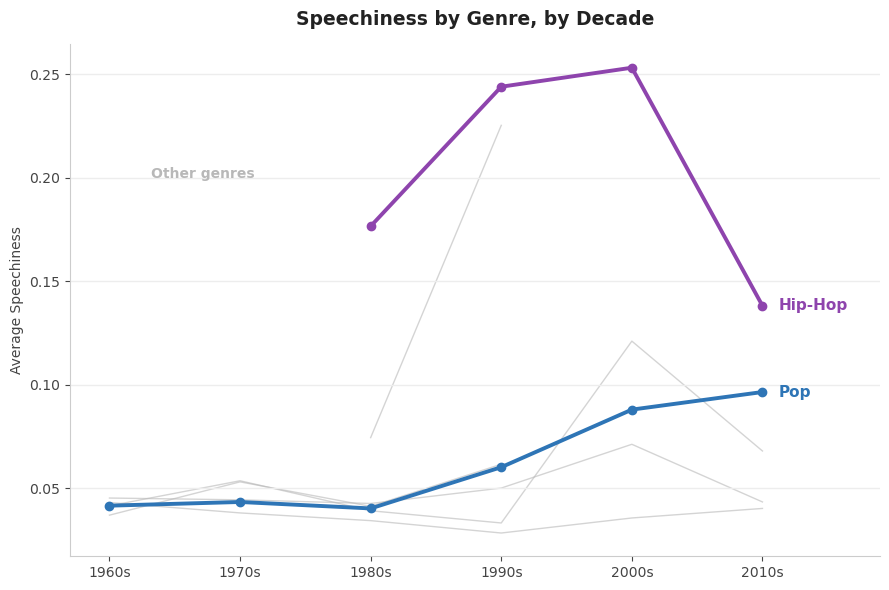

[SAVED] rq3_speechiness_by_genre_line.png


In [30]:
print("[STEP 25] Speechiness by Genre, by Decade")

GRAY = '#B8B8B8'
speech_decade_genre = genre_base.groupby(['decade','genre'])['speechiness'].mean().unstack()
decade_order = ['1960s','1970s','1980s','1990s','2000s','2010s']
speech_decade_genre = speech_decade_genre.reindex(decade_order)

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor('white')
ax.grid(axis='y', color='#EDEDED', linewidth=1, zorder=0)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')

x = range(len(decade_order))
for g in speech_decade_genre.columns:
    if g == 'pop':
        ax.plot(x, speech_decade_genre[g], color=POP_COLOR, linewidth=2.8, marker='o', markersize=6, zorder=5)
    elif g == 'hip hop':
        ax.plot(x, speech_decade_genre[g], color=HIPHOP_COLOR, linewidth=2.8, marker='o', markersize=6, zorder=5)
    else:
        ax.plot(x, speech_decade_genre[g], color=GRAY, linewidth=1, alpha=0.6, zorder=1)

# End-of-line labels instead of a legend box
last_x = len(decade_order) - 1
pop_last = speech_decade_genre['pop'].iloc[-1]
hh_last = speech_decade_genre['hip hop'].dropna().iloc[-1]
ax.text(last_x + 0.12, pop_last, 'Pop', color=POP_COLOR, fontsize=11, fontweight='bold', va='center')
ax.text(last_x + 0.12, hh_last, 'Hip-Hop', color=HIPHOP_COLOR, fontsize=11, fontweight='bold', va='center')
ax.text(0.1, 0.20, 'Other genres', color=GRAY, fontsize=10, fontweight='bold',
        transform=ax.get_yaxis_transform())

ax.set_xticks(list(x))
ax.set_xticklabels(decade_order, color='#444444')
ax.set_xlim(-0.3, last_x + 0.9)
ax.tick_params(colors='#444444')
ax.set_ylabel('Average Speechiness', color='#444444')
ax.set_title('Speechiness by Genre, by Decade', fontsize=13.5, fontweight='bold', color='#222222', pad=14)
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_by_genre_line.png', dpi=140, facecolor='white')
plt.show()
print('[SAVED] rq3_speechiness_by_genre_line.png')